In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd


# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods_2 import evaluate_metrics


In [2]:
# generate data
T = 1000
time = torch.linspace(0, 100, T)
time_series = torch.sin(time) + torch.randn(T) * 0.1  # Signal + Noise
time_series = time_series.view(-1, 1) # Ensure [L, 1] shape

In [3]:
## PYRO MODEL
def model_fn(states, scale=0.1, targets=None):
    N_neurons = states.shape[1]
    
    # Weights as a vector [N_neurons]
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons), 1.0).to_event(1))
    
    # mu calculation: [batch, neurons] @ [neurons] -> [batch]
    # We use .view(-1) to guarantee mu is a 1D vector of shape [batch_size]
    mu = (states @ R).view(-1)
    
    # 3. Noise
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    # 4. Observation
    with pyro.plate("data", states.shape[0]):
        obs_targets = targets.view(-1) if targets is not None else None
        
        return pyro.sample("obs", dist.Normal(mu, sigma), obs=obs_targets)

In [4]:
# PARAMETERS

N_NEURONS = 100
INPUT_DIM = 1 # equals to output dim

LR = 0.005
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [5]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [6]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=0.9
)


In [7]:
# Generate Torch datasets
train_ds, test_ds = construct_dataset(esn_var.reservoir, time_series, burnin=50)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

In [8]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   3%|▎         | 3/100 [00:04<01:43,  1.07s/it, Loss=183.0231]

Epoch 0 | Total ELBO Loss: 527.9749


Training Pyro ESN: 100%|██████████| 100/100 [00:11<00:00,  8.62it/s, Loss=11.5758]


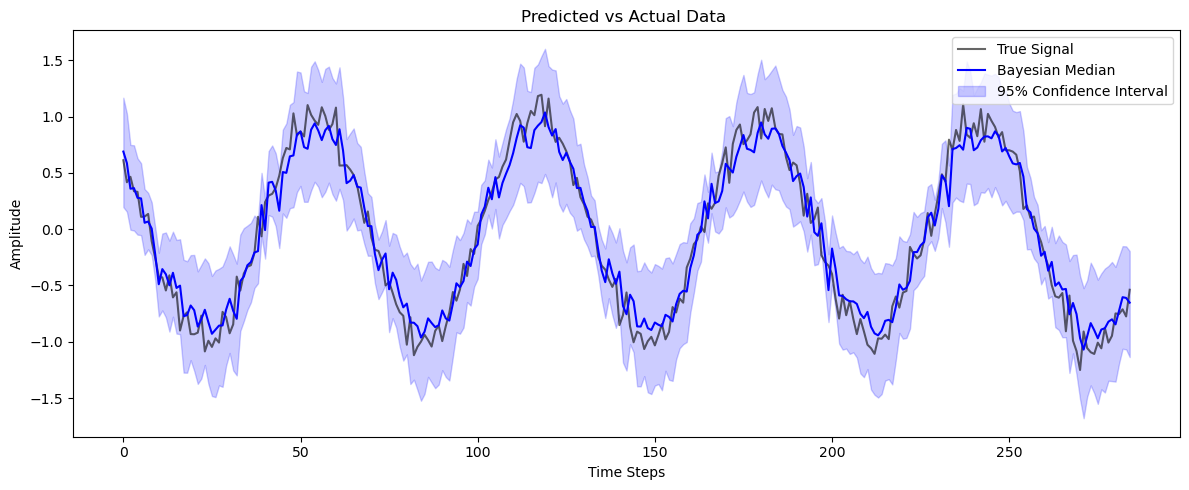

In [9]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler)

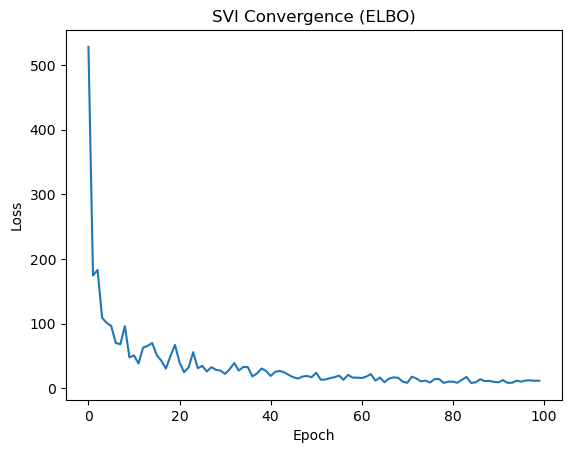

In [10]:
# Plot loss
plt.figure()
plt.plot(history)
plt.title("SVI Convergence (ELBO)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Metrics evaluation

In [11]:
ecov, cal, mcrps = evaluate_metrics(y_pred_samples=y_samples, y_true = y_true)

In [12]:
ecov, cal, mcrps

(0.9754385948181152, 0.0020071538829440736, tensor([0.0974]))

## Grid search (random)

In [13]:
# parameters space
neurons_list = [16, 32, 64, 128, 256, 512]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]

num_iterations = 10
results = []

for i in range(num_iterations):
    # Reset pyro paramteres between trials
    pyro.clear_param_store()
    
    # Sample parameters 
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}")

    try:
        optimizer = pyro.optim.Adam({"lr": lr})

        # PYRO GUIDE

        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # istantiate the model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=0.9,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # train
        esn_var.train(train_loader, epochs=150)

        # evaluate
        y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, test_ds, scaler, plot = False)
        
        # metrics
        ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'mcrps': mcrps
        })

    except Exception as e:
        print(f"Error at iteration: {e}")
        


--- Trial 1/10 ---
Parameters: Neurons=16, Activation=ReLU(), LR=0.0001, Scale=0.01


Training Pyro ESN:   1%|          | 1/150 [00:00<00:15,  9.39it/s, Loss=103433.4330]

Epoch 0 | Total ELBO Loss: 103433.4330


Training Pyro ESN:  53%|█████▎    | 79/150 [00:07<00:06, 10.91it/s, Loss=7759.1571] 


KeyboardInterrupt: 

In [ ]:
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['cal', 'ecov_dist', 'mcrps'])

print(best_models.head(5))


   neurons activation      lr  scale      ecov       cal     mcrps  ecov_dist
2       16     ReLU()  0.0100   1.00  1.000000  0.001448  0.246494   0.050000
5       16     ReLU()  0.0010   0.10  0.879518  0.002681  0.092154   0.070482
0      512     Tanh()  0.0010   0.10  0.903614  0.003209  0.096523   0.046386
3       32     Tanh()  0.0001   1.00  1.000000  0.004189  0.155095   0.050000
4      128     ReLU()  0.0100   0.01  0.847390  0.005591  0.086806   0.102610
